# CSU Campus Crime Count Model

**Prediction question:**  
Across CSU campuses, can we predict the annual reported criminal offense count using simple context features such as institution size, year, location type, campus, and prior-year crime history?

## Steps
1. Create a training set and test set from the original cleaned dataset.
2. Prepare the data with a preprocessing pipeline.
3. Train at least 3 different machine learning models.
4. Use N-fold cross-validation to compare models.
5. Select the best model.
6. Test the best model on the test set.

In [ ]:
# Import libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

pd.set_option("display.max_columns", 50)


## 1. Load cleaned crime datasets

This notebook uses the four **criminal offenses** cleaned CSV files:

- on campus
- student housing
- noncampus
- public property

Each row represents one campus, one year, and one location type. The target variable will be the total reported criminal offense count for that row.


In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/cs133/Cleaned'
except ModuleNotFoundError:
    path = '/mnt/data/Cleaned'

# We only want the criminal offense files for regression
crime_files = [
    "criminal_offenses_on_campus.csv",
    "criminal_offenses_on_student_housing.csv",
    "criminal_offenses_noncampus.csv",
    "criminal_offenses_public_property.csv"
]

df_list = []

for file_name in crime_files:
    file_path = os.path.join(path, file_name)
    temp = pd.read_csv(file_path)

    # Add a simple location type column based on the file name.
    if "on_campus" in file_name and "student_housing" not in file_name:
        temp["Location Type"] = "On Campus"
    elif "student_housing" in file_name:
        temp["Location Type"] = "Student Housing"
    elif "noncampus" in file_name:
        temp["Location Type"] = "Noncampus"
    elif "public_property" in file_name:
        temp["Location Type"] = "Public Property"

    df_list.append(temp)

crime_df = pd.concat(df_list, ignore_index=True)

print("Rows:", crime_df.shape[0])
print("Columns:", crime_df.shape[1])
crime_df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rows: 1231
Columns: 21


,Survey year,Unitid,Institution name,OPEID,Campus ID,Campus Name,Institution Size,Murder/Non-negligent manslaughter,Negligent manslaughter,Sex offenses - Forcible,Rape,Fondling,Sex offenses - Non-forcible,Incest,Statutory rape,Robbery,Aggravated assault,Burglary,Motor vehicle theft,Arson,Location Type
0,2015,110422,California Polytechnic State University-San Lu...,114300,1,Main Campus,20944,0,0,NaN,7,0,NaN,0,0,0,1,7,7,2,On Campus
1,2015,115755,California State Polytechnic University-Humboldt,114900,1,Cal Poly Humboldt,8790,0,0,NaN,6,3,NaN,0,0,0,8,10,2,4,On Campus
2,2015,110529,California State Polytechnic University-Pomona,114400,1,Main Campus,23717,0,0,NaN,4,6,NaN,0,1,1,0,8,18,1,On Campus
3,2015,111188,California State University Maritime Academy,113400,1,California State University Maritime Academy,1075,0,0,NaN,0,1,NaN,0,0,1,0,2,0,0,On Campus
4,2015,110486,California State University-Bakersfield,799300,1,Main Campus,9228,0,0,NaN,0,0,NaN,0,0,0,0,7,1,0,On Campus


## 2. Create prediction target

The dataset has separate columns for different crime categories. We add them to create the following:

**`Total Crime Count`** which is total reported criminal offenses for a campus, year, and location type.

This is our prediction target for the models


In [ ]:
# Columns that describe the campus/year/location
id_columns = [
    "Survey year",
    "Unitid",
    "Institution name",
    "OPEID",
    "Campus ID",
    " Campus Name",
    "Institution Size",
    "Location Type"
]

# All remaining columns are crime count columns
crime_columns = [col for col in crime_df.columns if col not in id_columns]

# Convert crime columns to numeric and replace missing values with 0
for col in crime_columns:
    crime_df[col] = pd.to_numeric(crime_df[col], errors="coerce").fillna(0)

crime_df["Total Crime Count"] = crime_df[crime_columns].sum(axis=1)

crime_df[[
    "Survey year", "Institution name", " Campus Name",
    "Institution Size", "Location Type", "Total Crime Count"
]].head()


,Survey year,Institution name,Campus Name,Institution Size,Location Type,Total Crime Count
0,2015,California Polytechnic State University-San Lu...,Main Campus,20944,On Campus,24.0
1,2015,California State Polytechnic University-Humboldt,Cal Poly Humboldt,8790,On Campus,33.0
2,2015,California State Polytechnic University-Pomona,Main Campus,23717,On Campus,39.0
3,2015,California State University Maritime Academy,California State University Maritime Academy,1075,On Campus,4.0
4,2015,California State University-Bakersfield,Main Campus,9228,On Campus,8.0


## 3. Add prev year feature

Same campus/location in previous year could be useful

So we make:

**`Previous Year Crime Count`**

This can help because crime history may impact annual crime count


In [ ]:
# Sort so calculated in correct order
crime_df = crime_df.sort_values([
    "Unitid", "Campus ID", "Location Type", "Survey year"
])

crime_df["Previous Year Crime Count"] = (
    crime_df
    .groupby(["Unitid", "Campus ID", "Location Type"])["Total Crime Count"]
    .shift(1)
)

# 1st year will not have a previous year so fill wwith 0
crime_df["Previous Year Crime Count"] = crime_df["Previous Year Crime Count"].fillna(0)

crime_df[[
    "Survey year", "Institution name", "Location Type",
    "Total Crime Count", "Previous Year Crime Count"
]].head(10)

,Survey year,Institution name,Location Type,Total Crime Count,Previous Year Crime Count
624,2015,California Polytechnic State University-San Lu...,Noncampus,4.0,0.0
643,2016,California Polytechnic State University-San Lu...,Noncampus,8.0,4.0
664,2017,California Polytechnic State University-San Lu...,Noncampus,5.0,8.0
688,2018,California Polytechnic State University-San Lu...,Noncampus,4.0,5.0
709,2019,California Polytechnic State University-San Lu...,Noncampus,0.0,4.0
734,2020,California Polytechnic State University-San Lu...,Noncampus,6.0,0.0
760,2021,California Polytechnic State University-San Lu...,Noncampus,9.0,6.0
785,2022,California Polytechnic State University-San Lu...,Noncampus,9.0,9.0
812,2023,California Polytechnic State University-San Lu...,Noncampus,11.0,9.0
0,2015,California Polytechnic State University-San Lu...,On Campus,24.0,0.0


## 4. Choose features and target

**Features:**

- survey year
- institution size
- previous year crime count
- institution name
- campus name
- location type

**Target:**

- total crime count


In [ ]:
features = [
    "Survey year",
    "Institution Size",
    "Previous Year Crime Count",
    "Institution name",
    " Campus Name",
    "Location Type"
]

target = "Total Crime Count"

X = crime_df[features]
y = crime_df[target]

X.head()

,Survey year,Institution Size,Previous Year Crime Count,Institution name,Campus Name,Location Type
624,2015,20944,0.0,California Polytechnic State University-San Lu...,Main Campus,Noncampus
643,2016,21306,4.0,California Polytechnic State University-San Lu...,Main Campus,Noncampus
664,2017,22370,8.0,California Polytechnic State University-San Lu...,Main Campus,Noncampus
688,2018,22013,5.0,California Polytechnic State University-San Lu...,Main Campus,Noncampus
709,2019,21426,4.0,California Polytechnic State University-San Lu...,Main Campus,Noncampus


## 5. Create the training and test sets


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 984
Testing rows: 247


## 6. Build preprocessing pipeline

This will handle:

- missing values
- scaling numeric columns
- one-hot encoding categorical columns

In [ ]:
numeric_features = [
    "Survey year",
    "Institution Size",
    "Previous Year Crime Count"
]

categorical_features = [
    "Institution name",
    " Campus Name",
    "Location Type"
]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

## 7. Train and compare 3 different models

We will compare the following models:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

Because the target is a numeric count, this is a **regression** problem.  
We use these metrics:

- **MAE**: average absolute prediction error
- **RMSE**: gives a larger penalty to big errors
- **R²**: how much variation the model explains

For MAE and RMSE, lower is better.  
For R^2, higher is better.


In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2"
        }
    )

    results.append({
        "Model": model_name,
        "CV MAE": -cv_results["test_mae"].mean(),
        "CV RMSE": -cv_results["test_rmse"].mean(),
        "CV R2": cv_results["test_r2"].mean()
    })

results_df = pd.DataFrame(results).sort_values("CV RMSE")
results_df

,Model,CV MAE,CV RMSE,CV R2
2,Random Forest,4.710040,12.765916,0.417015
0,Linear Regression,7.313442,14.424371,0.249151
1,Decision Tree,6.012732,16.782898,-0.300707


## 8. Visualize comparison

The model with the lowest cross-validation RMSE will be selected as the best model.


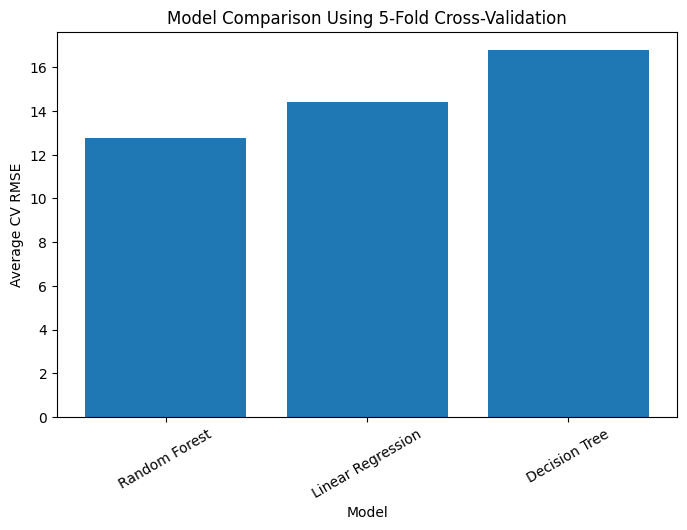

Best model based on lowest CV RMSE: Random Forest


In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["CV RMSE"])
plt.title("Model Comparison Using 5-Fold Cross-Validation")
plt.xlabel("Model")
plt.ylabel("Average CV RMSE")
plt.xticks(rotation=30)
plt.show()

best_model_name = results_df.iloc[0]["Model"]
print("Best model based on lowest CV RMSE:", best_model_name)

## 9. Train the best model on the full training set

After cross-validation, we train the selected model using the full training set.


In [ ]:
best_model = models[best_model_name]

best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

best_pipeline.fit(X_train, y_train)

print("Final model trained:", best_model_name)

Final model trained: Random Forest


## 10. Test the best model on the test set

Now we evaluate the best model on new data


In [ ]:
y_pred = best_pipeline.predict(X_test)

test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

print("Test MAE:", round(test_mae, 2))
print("Test RMSE:", round(test_rmse, 2))
print("Test R2:", round(test_r2, 3))

Test MAE: 4.3
Test RMSE: 12.22
Test R2: 0.242


## 11. Compare actual vs predicted values

This shows a sample of the model's predictions compared to real crime counts


In [ ]:
prediction_results = X_test.copy()
prediction_results["Actual Crime Count"] = y_test
prediction_results["Predicted Crime Count"] = y_pred.round(1)
prediction_results["Prediction Error"] = (
    prediction_results["Actual Crime Count"] - prediction_results["Predicted Crime Count"]
).round(1)

prediction_results.head(10)

,Survey year,Institution Size,Previous Year Crime Count,Institution name,Campus Name,Location Type,Actual Crime Count,Predicted Crime Count,Prediction Error
1203,2023,40278,2.0,California State University-Long Beach,Main Campus,Public Property,5.0,2.5,2.5
639,2015,12793,0.0,California State University-San Marcos,Main Campus,Noncampus,0.0,2.0,-2.0
1146,2022,14183,0.0,California State University-Chico,Agricultural Teaching and Research Center/Univ...,Public Property,0.0,0.0,0.0
480,2018,37466,7.0,California State University-Long Beach,Main Campus,Student Housing,4.0,9.9,-5.9
280,2021,7503,0.0,California State University-Monterey Bay,CSUMB at Cuesta College,On Campus,0.0,0.0,0.0
594,2022,25282,0.0,San Francisco State University,The Estuary & Ocean Science Center,Student Housing,0.0,0.0,0.0
1141,2022,849,0.0,California State University Maritime Academy,The Training Ship Golden Bear,Public Property,0.0,1.5,-1.5
698,2018,37466,1.0,California State University-Long Beach,Main Campus,Noncampus,3.0,2.0,1.0
242,2020,11163,0.0,California State University-Stanislaus,CSU Stanislaus - Stockton,On Campus,0.0,0.0,0.0
1073,2020,19689,0.0,California State University-San Bernardino,California State University- San Bernardino,Public Property,0.0,0.2,-0.2


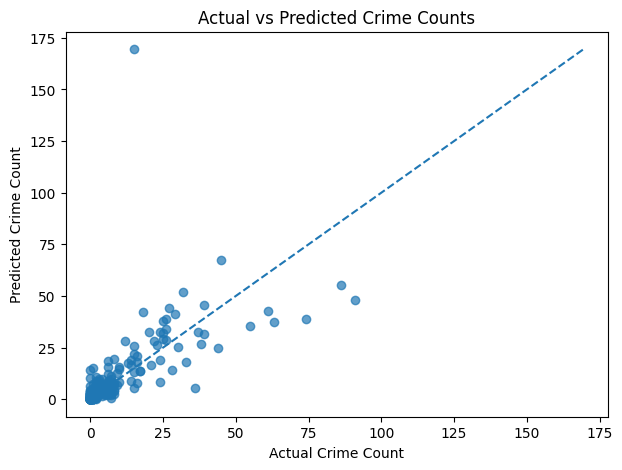

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.7)

# Add a diagonal line for regression.
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.title("Actual vs Predicted Crime Counts")
plt.xlabel("Actual Crime Count")
plt.ylabel("Predicted Crime Count")
plt.show()
